# NLP Midterm Project - Group 02 - AI Content Detection
Dataset 1: DAIGT V2 Train Dataset

Dataset 1 Link: https://www.kaggle.com/datasets/thedrcat/daigt-v2-train-dataset/data                                           

Dataset 2: HC3 (Human ChatGPT Comparison Corpus)

Dataset 2 Link: https://huggingface.co/datasets/Hello-SimpleAI/HC3

Algorithms: Multinomial Naive Bayes, Logistic Regression, LinearSVC

Representations: Bag of Words, TF-IDF

### Import libraries and download NLTK resources

In [23]:
import re
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

### Extract Dataset from Google Drive Links

In [24]:
SAMPLE_PER_CLASS = 3000
path_daigt_download = 'https://drive.google.com/uc?export=download&id=1L1a5lPNUSjmLA167XT3Yv-S55d9FaW0U'
path_hc3_download = 'https://drive.google.com/uc?export=download&id=1Dse8l3ct3elof5gqvVWcl0_Wfm38RsV0'
print('Google Drive download links for DAIGT V2 and HC3 datasets are configured.')

Google Drive download links for DAIGT V2 and HC3 datasets are configured.


### Read Dataset 1: DAIGT V2 Train Dataset

In [25]:
daigt_raw = pd.read_csv(path_daigt_download)

df1 = daigt_raw[['text', 'label']].dropna()
df1['label'] = df1['label'].astype(int)

print("=" * 60)
print("Dataset 1: DAIGT V2 Train Dataset")
print("Dataset Summary")
print("=" * 60)

print(f"Total Samples : {len(df1):,}")
print(f"Total Columns : {df1.shape[1]}")

print("\nClass Distribution")
print(df1['label']
      .value_counts()
      .sort_index()
      .rename_axis("Label")
      .reset_index(name="Number of Samples"))

print("\nFirst 5 Records")
print(df1.head())


Dataset 1: DAIGT V2 Train Dataset
Dataset Summary
Total Samples : 44,868
Total Columns : 2

Class Distribution
   Label  Number of Samples
0      0              27371
1      1              17497

First 5 Records
                                                text  label
0  Phones\n\nModern humans today are always on th...      0
1  This essay will explain if drivers should or s...      0
2  Driving while the use of cellular devices\n\nT...      0
3  Phones & Driving\n\nDrivers should not be able...      0
4  Cell Phone Operation While Driving\n\nThe abil...      0


### Read Dataset 2:  HC3 (Human ChatGPT Comparison Corpus)

In [26]:
hc3_raw = pd.read_json(path_hc3_download, lines=True)

human = (
    hc3_raw[['human_answers']]
    .explode('human_answers')
    .rename(columns={'human_answers': 'text'})
)
human['label'] = 0

chatgpt = (
    hc3_raw[['chatgpt_answers']]
    .explode('chatgpt_answers')
    .rename(columns={'chatgpt_answers': 'text'})
)
chatgpt['label'] = 1

df2 = pd.concat([human, chatgpt], ignore_index=True).dropna()
df2['text'] = df2['text'].astype(str)

print("=" * 60)
print("Dataset 2: HC3 (Human ChatGPT Comparison Corpus)")
print("Dataset Summary")
print("=" * 60)

print(f"Total Samples : {len(df2):,}")
print(f"Total Columns : {df2.shape[1]}")

print("\nClass Distribution")
print(df2['label'].value_counts().sort_index().rename_axis("Label").reset_index(name="Number of Samples"))

print("\nFirst 5 Records")
print(df2.head())


Dataset 2: HC3 (Human ChatGPT Comparison Corpus)
Dataset Summary
Total Samples : 85,449
Total Columns : 2

Class Distribution
   Label  Number of Samples
0      0              58546
1      1              26903

First 5 Records
                                                text  label
0  Basically there are many categories of " Best ...      0
1  If you 're hearing about it , it 's because it...      0
2  One reason is lots of catagories . However , h...      0
3  salt is good for not dying in car crashes and ...      0
4  In Minnesota and North Dakota , they tend to u...      0


### Balance both datasets by sampling equal rows per class

In [27]:
def balance(df, n, seed=42):
    parts = []
    for value in sorted(df['label'].unique()):
        subset = df[df['label'] == value]
        parts.append(subset.sample(n=min(n, len(subset)), random_state=seed))
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

df1 = balance(df1, SAMPLE_PER_CLASS)
df2 = balance(df2, SAMPLE_PER_CLASS)

print("=" * 50)
print("Dataset 1: DAIGT V2 Train Dataset")
print("Class Distribution After Balancing")
print("=" * 50)
print(df1['label'].value_counts().sort_index().rename_axis("Label").reset_index(name="Number of Rows"))

print("\n" + "=" * 50)
print("Dataset 2: HC3 (Human ChatGPT Comparison Corpus)")
print("Class Distribution After Balancing")
print("=" * 50)
print(df2['label'].value_counts().sort_index().rename_axis("Label").reset_index(name="Number of Rows"))


Dataset 1: DAIGT V2 Train Dataset
Class Distribution After Balancing
   Label  Number of Rows
0      0            3000
1      1            3000

Dataset 2: HC3 (Human ChatGPT Comparison Corpus)
Class Distribution After Balancing
   Label  Number of Rows
0      0            3000
1      1            3000


### Preprocess text (case folding, punctuation removal, tokenization, stop word removal, lemmatization)

In [28]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens if tok not in stop_words and len(tok) > 1]
    return ' '.join(tokens)

df1['clean_text'] = df1['text'].apply(preprocess)
df2['clean_text'] = df2['text'].apply(preprocess)

print('Sample of Preprocessed Text for Dataset 1 (DAIGT V2):')
print(df1[['text', 'clean_text']].head())
print('\nSample of Preprocessed Text for Dataset 2 (HC3):')
print(df2[['text', 'clean_text']].head())

Sample of Preprocessed Text for Dataset 1 (DAIGT V2):
                                                text  \
0  Dear TEACHER_NAME,\n\nI think the idea of havi...   
1  Hey there!  So, you wanna know about how havin...   
2  Generic_Name\n\nGeneric_Name\n\nEnglish 8 Hono...   
3  The school bus doors close with a hiss behind ...   
4  It is no secret that cars have become a staple...   

                                          clean_text  
0  dear teacher name think idea principal making ...  
1  hey wan na know positive attitude lead success...  
2  generic name generic name english honor asking...  
3  school bus door close hiss behind walk drivewa...  
4  secret car become staple american life use get...  

Sample of Preprocessed Text for Dataset 2 (HC3):
                                                text  \
0  20 second solver here . We solve the first two...   
1  Sure! Declension in German refers to the way t...   
2  Hi there, as you had fall 2 weeks back and I s...   
3  Th

### Train / test split for both datasets

In [29]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    df1['clean_text'], df1['label'], test_size=0.2, random_state=42, stratify=df1['label'])

X2_train, X2_test, y2_train, y2_test = train_test_split(
    df2['clean_text'], df2['label'], test_size=0.2, random_state=42, stratify=df2['label'])

print(f'Dataset 1 (DAIGT V2) Training set size: {len(X1_train)} samples')
print(f'Dataset 1 (DAIGT V2) Testing set size: {len(X1_test)} samples')
print(f'Dataset 2 (HC3) Training set size: {len(X2_train)} samples')
print(f'Dataset 2 (HC3) Testing set size: {len(X2_test)} samples')

Dataset 1 (DAIGT V2) Training set size: 4800 samples
Dataset 1 (DAIGT V2) Testing set size: 1200 samples
Dataset 2 (HC3) Training set size: 4800 samples
Dataset 2 (HC3) Testing set size: 1200 samples


### Bag of Words (BoW) Feature Extraction

In [30]:
from sklearn.feature_extraction.text import CountVectorizer

bow1 = CountVectorizer()
X1_train_bow = bow1.fit_transform(X1_train)
X1_test_bow = bow1.transform(X1_test)

bow2 = CountVectorizer()
X2_train_bow = bow2.fit_transform(X2_train)
X2_test_bow = bow2.transform(X2_test)

print("=" * 70)
print("Bag of Words (BoW) Feature Extraction Summary")
print("=" * 70)

print("\nDataset 1: DAIGT V2 Train Dataset")
print(f"Training Feature Matrix Shape : {X1_train_bow.shape}")
print(f"Testing Feature Matrix Shape  : {X1_test_bow.shape}")
print(f"Vocabulary Size               : {len(bow1.vocabulary_):,}")

print("\nDataset 2: HC3 (Human ChatGPT Comparison Corpus)")
print(f"Training Feature Matrix Shape : {X2_train_bow.shape}")
print(f"Testing Feature Matrix Shape  : {X2_test_bow.shape}")
print(f"Vocabulary Size               : {len(bow2.vocabulary_):,}")

Bag of Words (BoW) Feature Extraction Summary

Dataset 1: DAIGT V2 Train Dataset
Training Feature Matrix Shape : (4800, 20465)
Testing Feature Matrix Shape  : (1200, 20465)
Vocabulary Size               : 20,465

Dataset 2: HC3 (Human ChatGPT Comparison Corpus)
Training Feature Matrix Shape : (4800, 19599)
Testing Feature Matrix Shape  : (1200, 19599)
Vocabulary Size               : 19,599


### TF-IDF Feature Extraction

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf1 = TfidfVectorizer()
X1_train_tfidf = tfidf1.fit_transform(X1_train)
X1_test_tfidf = tfidf1.transform(X1_test)

tfidf2 = TfidfVectorizer()
X2_train_tfidf = tfidf2.fit_transform(X2_train)
X2_test_tfidf = tfidf2.transform(X2_test)


print("=" * 70)
print("TF-IDF Feature Extraction Summary")
print("=" * 70)

print("\nDataset 1: DAIGT V2 Train Dataset")
print(f"Training Feature Matrix Shape : {X1_train_tfidf.shape}")
print(f"Testing Feature Matrix Shape  : {X1_test_tfidf.shape}")
print(f"Vocabulary Size               : {len(tfidf1.vocabulary_):,}")

print("\nDataset 2: HC3 (Human ChatGPT Comparison Corpus)")
print(f"Training Feature Matrix Shape : {X2_train_tfidf.shape}")
print(f"Testing Feature Matrix Shape  : {X2_test_tfidf.shape}")
print(f"Vocabulary Size               : {len(tfidf2.vocabulary_):,}")

TF-IDF Feature Extraction Summary

Dataset 1: DAIGT V2 Train Dataset
Training Feature Matrix Shape : (4800, 20465)
Testing Feature Matrix Shape  : (1200, 20465)
Vocabulary Size               : 20,465

Dataset 2: HC3 (Human ChatGPT Comparison Corpus)
Training Feature Matrix Shape : (4800, 19599)
Testing Feature Matrix Shape  : (1200, 19599)
Vocabulary Size               : 19,599


### Evaluation helper and results container

In [32]:
results = {}
print("The 'results' dictionary will store evaluation metrics. The 'evaluate' function trains a model, makes predictions, and calculates key performance indicators like accuracy, precision, recall, and F1 score.")

def evaluate(model, X_train, y_train, X_test, y_test, title):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions, average='weighted', zero_division=0)
    rec = recall_score(y_test, predictions, average='weighted', zero_division=0)
    f1 = f1_score(y_test, predictions, average='weighted', zero_division=0)
    print(title)
    print(classification_report(y_test, predictions))
    print('Accuracy:', acc)
    print('-' * 60)
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'y_true': y_test, 'y_pred': predictions}

print("'evaluate' function defined and ready for use.")

The 'results' dictionary will store evaluation metrics. The 'evaluate' function trains a model, makes predictions, and calculates key performance indicators like accuracy, precision, recall, and F1 score.
'evaluate' function defined and ready for use.


### Naive Bayes (MultinomialNB)

In [33]:
results[('Naive Bayes', 'BoW', 'Dataset 1')] = evaluate(MultinomialNB(), X1_train_bow, y1_train, X1_test_bow, y1_test, 'Naive Bayes | BoW | Dataset 1 (DAIGT V2)')
results[('Naive Bayes', 'TF-IDF', 'Dataset 1')] = evaluate(MultinomialNB(), X1_train_tfidf, y1_train, X1_test_tfidf, y1_test, 'Naive Bayes | TF-IDF | Dataset 1 (DAIGT V2)')
results[('Naive Bayes', 'BoW', 'Dataset 2')] = evaluate(MultinomialNB(), X2_train_bow, y2_train, X2_test_bow, y2_test, 'Naive Bayes | BoW | Dataset 2 (HC3)')
results[('Naive Bayes', 'TF-IDF', 'Dataset 2')] = evaluate(MultinomialNB(), X2_train_tfidf, y2_train, X2_test_tfidf, y2_test, 'Naive Bayes | TF-IDF | Dataset 2 (HC3)')
print('Naive Bayes model evaluation results stored in the results dictionary.')

Naive Bayes | BoW | Dataset 1 (DAIGT V2)
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       600
           1       0.98      0.93      0.96       600

    accuracy                           0.96      1200
   macro avg       0.96      0.96      0.96      1200
weighted avg       0.96      0.96      0.96      1200

Accuracy: 0.9566666666666667
------------------------------------------------------------
Naive Bayes | TF-IDF | Dataset 1 (DAIGT V2)
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       600
           1       0.97      0.93      0.95       600

    accuracy                           0.95      1200
   macro avg       0.95      0.95      0.95      1200
weighted avg       0.95      0.95      0.95      1200

Accuracy: 0.9508333333333333
------------------------------------------------------------
Naive Bayes | BoW | Dataset 2 (HC3)
              precision    recall  f1-score  

### Confusion matrices for Naive Bayes

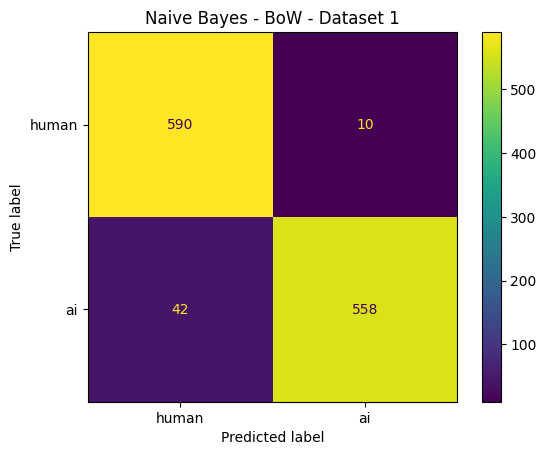

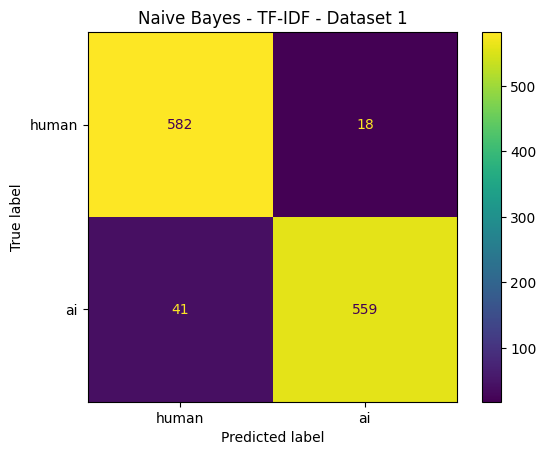

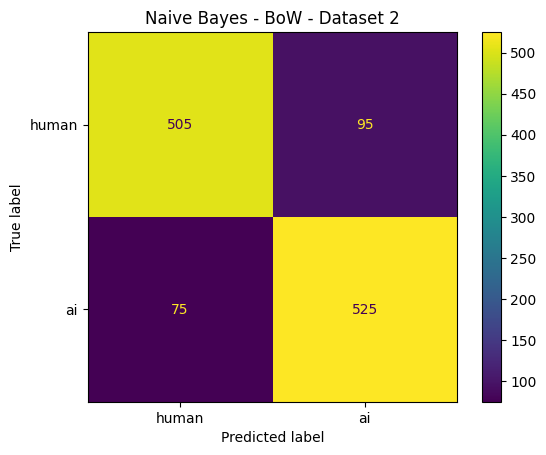

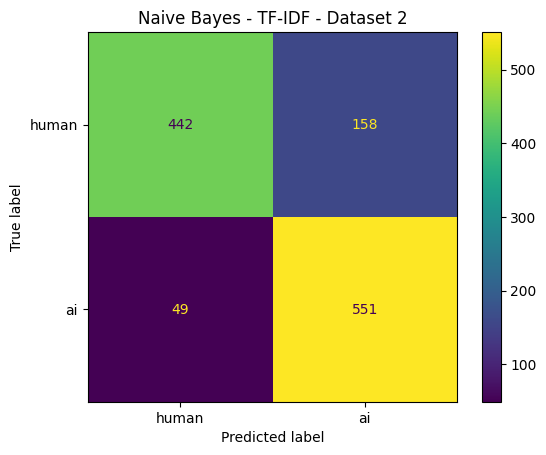

Confusion matrices for Naive Bayes models displayed above.


In [34]:
combos = [('BoW', 'Dataset 1'), ('TF-IDF', 'Dataset 1'), ('BoW', 'Dataset 2'), ('TF-IDF', 'Dataset 2')]
for rep, ds in combos:
    scores = results[('Naive Bayes', rep, ds)]
    ConfusionMatrixDisplay(confusion_matrix(scores['y_true'], scores['y_pred']), display_labels=['human', 'ai']).plot()
    plt.title('Naive Bayes' + ' - ' + rep + ' - ' + ds)
    plt.show()
print('Confusion matrices for Naive Bayes models displayed above.')

### Logistic Regression

In [35]:
results[('Logistic Regression', 'BoW', 'Dataset 1')] = evaluate(LogisticRegression(max_iter=1000), X1_train_bow, y1_train, X1_test_bow, y1_test, 'Logistic Regression | BoW | Dataset 1 (DAIGT V2)')
results[('Logistic Regression', 'TF-IDF', 'Dataset 1')] = evaluate(LogisticRegression(max_iter=1000), X1_train_tfidf, y1_train, X1_test_tfidf, y1_test, 'Logistic Regression | TF-IDF | Dataset 1 (DAIGT V2)')
results[('Logistic Regression', 'BoW', 'Dataset 2')] = evaluate(LogisticRegression(max_iter=1000), X2_train_bow, y2_train, X2_test_bow, y2_test, 'Logistic Regression | BoW | Dataset 2 (HC3)')
results[('Logistic Regression', 'TF-IDF', 'Dataset 2')] = evaluate(LogisticRegression(max_iter=1000), X2_train_tfidf, y2_train, X2_test_tfidf, y2_test, 'Logistic Regression | TF-IDF | Dataset 2 (HC3)')
print('Logistic Regression model evaluation results stored in the results dictionary.')

Logistic Regression | BoW | Dataset 1 (DAIGT V2)
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       600
           1       0.99      0.97      0.98       600

    accuracy                           0.98      1200
   macro avg       0.98      0.98      0.98      1200
weighted avg       0.98      0.98      0.98      1200

Accuracy: 0.9825
------------------------------------------------------------
Logistic Regression | TF-IDF | Dataset 1 (DAIGT V2)
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       600
           1       0.99      0.96      0.98       600

    accuracy                           0.98      1200
   macro avg       0.98      0.98      0.98      1200
weighted avg       0.98      0.98      0.98      1200

Accuracy: 0.9758333333333333
------------------------------------------------------------
Logistic Regression | BoW | Dataset 2 (HC3)
              precision    recall

### Confusion matrices for Logistic Regression

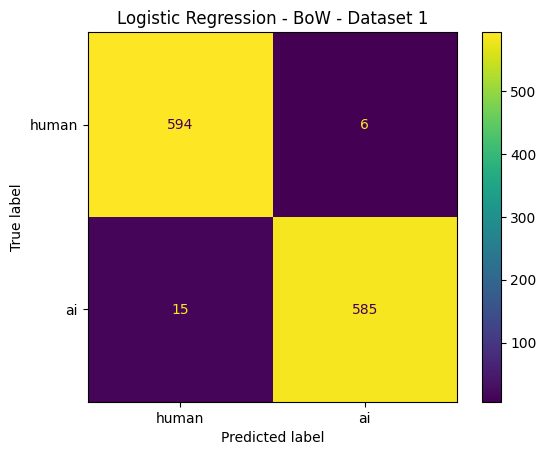

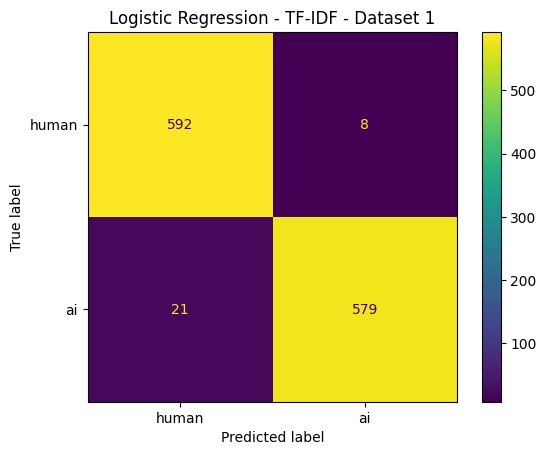

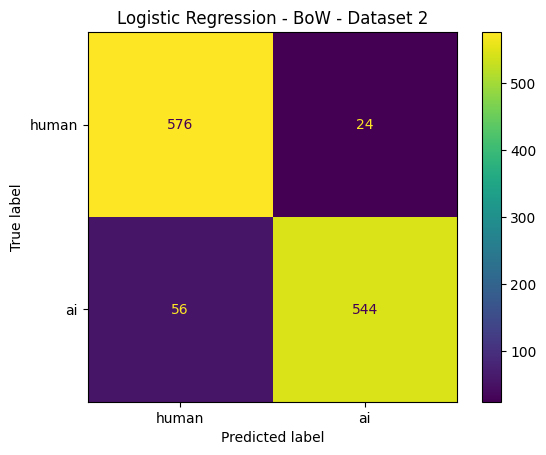

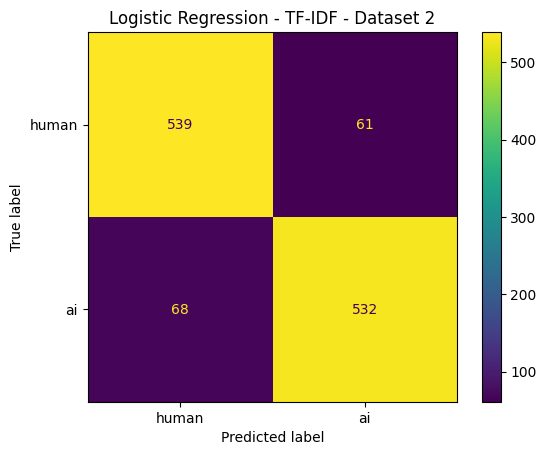

Confusion matrices for Logistic Regression models displayed above.


In [36]:
combos = [('BoW', 'Dataset 1'), ('TF-IDF', 'Dataset 1'), ('BoW', 'Dataset 2'), ('TF-IDF', 'Dataset 2')]
for rep, ds in combos:
    scores = results[('Logistic Regression', rep, ds)]
    ConfusionMatrixDisplay(confusion_matrix(scores['y_true'], scores['y_pred']), display_labels=['human', 'ai']).plot()
    plt.title('Logistic Regression' + ' - ' + rep + ' - ' + ds)
    plt.show()
print('Confusion matrices for Logistic Regression models displayed above.')

### Support Vector Machine (LinearSVC)

In [37]:
results[('Support Vector Machine', 'BoW', 'Dataset 1')] = evaluate(LinearSVC(max_iter=5000), X1_train_bow, y1_train, X1_test_bow, y1_test, 'Support Vector Machine | BoW | Dataset 1 (DAIGT V2)')
results[('Support Vector Machine', 'TF-IDF', 'Dataset 1')] = evaluate(LinearSVC(max_iter=5000), X1_train_tfidf, y1_train, X1_test_tfidf, y1_test, 'Support Vector Machine | TF-IDF | Dataset 1 (DAIGT V2)')
results[('Support Vector Machine', 'BoW', 'Dataset 2')] = evaluate(LinearSVC(max_iter=5000), X2_train_bow, y2_train, X2_test_bow, y2_test, 'Support Vector Machine | BoW | Dataset 2 (HC3)')
results[('Support Vector Machine', 'TF-IDF', 'Dataset 2')] = evaluate(LinearSVC(max_iter=5000), X2_train_tfidf, y2_train, X2_test_tfidf, y2_test, 'Support Vector Machine | TF-IDF | Dataset 2 (HC3)')
print('Support Vector Machine model evaluation results stored in the results dictionary.')

Support Vector Machine | BoW | Dataset 1 (DAIGT V2)
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       600
           1       0.98      0.97      0.98       600

    accuracy                           0.98      1200
   macro avg       0.98      0.98      0.98      1200
weighted avg       0.98      0.98      0.98      1200

Accuracy: 0.9775
------------------------------------------------------------
Support Vector Machine | TF-IDF | Dataset 1 (DAIGT V2)
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       600
           1       1.00      0.98      0.99       600

    accuracy                           0.99      1200
   macro avg       0.99      0.99      0.99      1200
weighted avg       0.99      0.99      0.99      1200

Accuracy: 0.9875
------------------------------------------------------------
Support Vector Machine | BoW | Dataset 2 (HC3)
              precision    recall  f

### Confusion matrices for Support Vector Machine

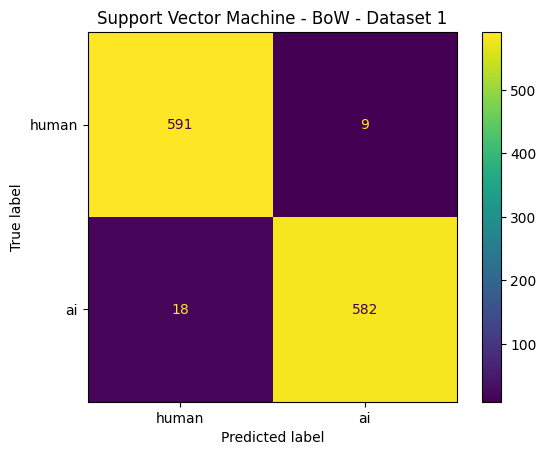

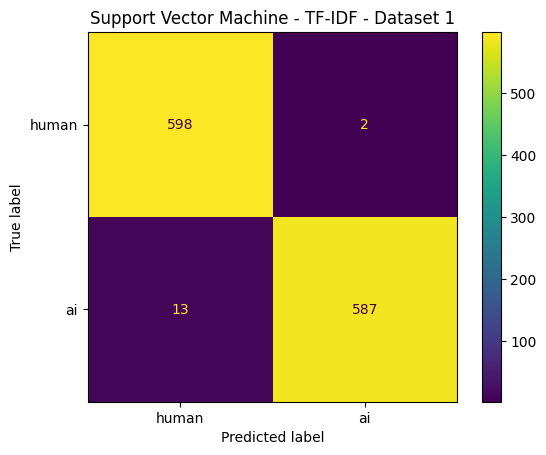

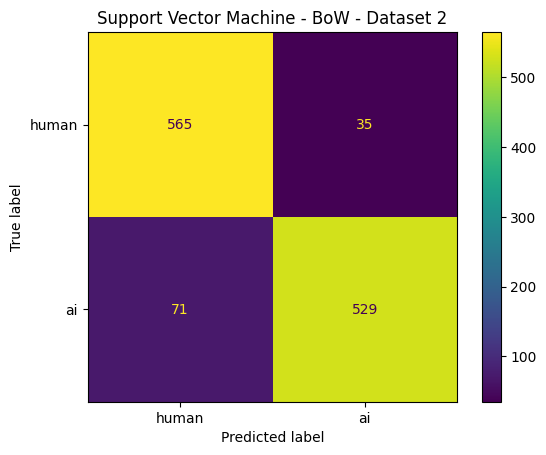

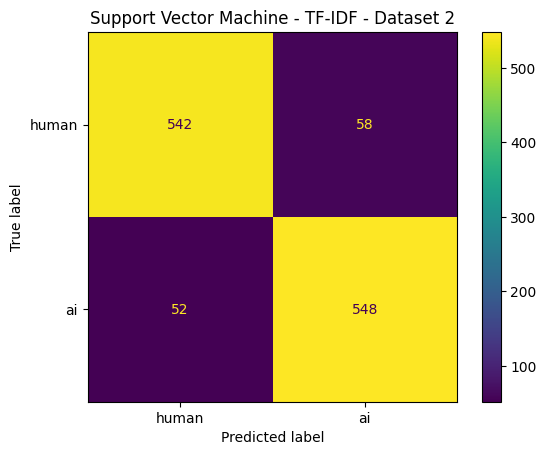

Confusion matrices for Support Vector Machine models displayed above.


In [38]:
combos = [('BoW', 'Dataset 1'), ('TF-IDF', 'Dataset 1'), ('BoW', 'Dataset 2'), ('TF-IDF', 'Dataset 2')]
for rep, ds in combos:
    scores = results[('Support Vector Machine', rep, ds)]
    ConfusionMatrixDisplay(confusion_matrix(scores['y_true'], scores['y_pred']), display_labels=['human', 'ai']).plot()
    plt.title('Support Vector Machine' + ' - ' + rep + ' - ' + ds)
    plt.show()
print('Confusion matrices for Support Vector Machine models displayed above.')

### Detailed metrics per algorithm (Accuracy, Precision, Recall, F1)

In [39]:
combos = [('BoW', 'Dataset 1'), ('TF-IDF', 'Dataset 1'), ('BoW', 'Dataset 2'), ('TF-IDF', 'Dataset 2')]

for algo in ['Naive Bayes', 'Logistic Regression', 'Support Vector Machine']:
    table_rows = []
    for rep, ds in combos:
        scores = results[(algo, rep, ds)]
        table_rows.append({
            'Representation': rep,
            'Dataset': ds,
            'Accuracy': round(scores['Accuracy'], 4),
            'Precision': round(scores['Precision'], 4),
            'Recall': round(scores['Recall'], 4),
            'F1': round(scores['F1'], 4)
        })
    print(algo)
    print(pd.DataFrame(table_rows).to_string(index=False))
    print('=' * 70)

Naive Bayes
Representation   Dataset  Accuracy  Precision  Recall     F1
           BoW Dataset 1    0.9567     0.9580  0.9567 0.9566
        TF-IDF Dataset 1    0.9508     0.9515  0.9508 0.9508
           BoW Dataset 2    0.8583     0.8587  0.8583 0.8583
        TF-IDF Dataset 2    0.8275     0.8387  0.8275 0.8261
Logistic Regression
Representation   Dataset  Accuracy  Precision  Recall     F1
           BoW Dataset 1    0.9825     0.9826  0.9825 0.9825
        TF-IDF Dataset 1    0.9758     0.9761  0.9758 0.9758
           BoW Dataset 2    0.9333     0.9346  0.9333 0.9333
        TF-IDF Dataset 2    0.8925     0.8926  0.8925 0.8925
Support Vector Machine
Representation   Dataset  Accuracy  Precision  Recall     F1
           BoW Dataset 1    0.9775     0.9776  0.9775 0.9775
        TF-IDF Dataset 1    0.9875     0.9877  0.9875 0.9875
           BoW Dataset 2    0.9117     0.9132  0.9117 0.9116
        TF-IDF Dataset 2    0.9083     0.9084  0.9083 0.9083


### Final result table (accuracy)

In [40]:
rows = []
for algo in ['Naive Bayes', 'Logistic Regression', 'Support Vector Machine']:
    for rep in ['BoW', 'TF-IDF']:
        rows.append({
            'Algorithm': algo,
            'Representation': rep,
            'Dataset 1': round(results[(algo, rep, 'Dataset 1')]['Accuracy'], 4),
            'Dataset 2': round(results[(algo, rep, 'Dataset 2')]['Accuracy'], 4)
        })

final_table = pd.DataFrame(rows)
print(final_table.to_string(index=False))

             Algorithm Representation  Dataset 1  Dataset 2
           Naive Bayes            BoW     0.9567     0.8583
           Naive Bayes         TF-IDF     0.9508     0.8275
   Logistic Regression            BoW     0.9825     0.9333
   Logistic Regression         TF-IDF     0.9758     0.8925
Support Vector Machine            BoW     0.9775     0.9117
Support Vector Machine         TF-IDF     0.9875     0.9083


### Export sample dataset file 1 (DAIGT V2) - first 100 rows, all 5 columns

In [41]:
sample1 = daigt_raw.head(100)

print("=" * 60)
print("Sample Dataset 1 (DAIGT V2) for Submission")
print("=" * 60)
print(f"Rows    : {sample1.shape[0]}")
print(f"Columns : {sample1.shape[1]} -> {list(sample1.columns)}")
print()
print(sample1.to_string(max_colwidth=30))

Sample Dataset 1 (DAIGT V2) for Submission
Rows    : 100
Columns : 5 -> ['text', 'label', 'prompt_name', 'source', 'RDizzl3_seven']

                             text  label         prompt_name           source  RDizzl3_seven
0   Phones\n\nModern humans to...      0  Phones and driving  persuade_corpus          False
1   This essay will explain if...      0  Phones and driving  persuade_corpus          False
2   Driving while the use of c...      0  Phones and driving  persuade_corpus          False
3   Phones & Driving\n\nDriver...      0  Phones and driving  persuade_corpus          False
4   Cell Phone Operation While...      0  Phones and driving  persuade_corpus          False
5   Cell phone use should not ...      0  Phones and driving  persuade_corpus          False
6   Phones and Driving\n\nDriv...      0  Phones and driving  persuade_corpus          False
7   PHONES AND DRIVING\n\nIn t...      0  Phones and driving  persuade_corpus          False
8   People are debating whethe

### Export sample dataset file 2 (HC3) - first 100 rows, all 5 columns

In [42]:
sample2 = hc3_raw.head(100)

print("=" * 60)
print("Sample Dataset 2 (HC3) for Submission")
print("=" * 60)
print(f"Rows    : {sample2.shape[0]}")
print(f"Columns : {sample2.shape[1]} -> {list(sample2.columns)}")
print()
print(sample2.to_string(max_colwidth=30))

Sample Dataset 2 (HC3) for Submission
Rows    : 100
Columns : 5 -> ['question', 'human_answers', 'chatgpt_answers', 'index', 'source']

                         question                  human_answers                chatgpt_answers  index       source
0   Why is every book I hear a...  [Basically there are many ...  [There are many different ...    NaN  reddit_eli5
1   If salt is so bad for cars...  [salt is good for not dyin...  [Salt is used on roads to ...    NaN  reddit_eli5
2   Why do we still have SD TV...  [The way it works is that ...  [There are a few reasons w...    NaN  reddit_eli5
3   Why has nobody assassinate...  [You ca n't just go around...  [It is generally not accep...    NaN  reddit_eli5
4   How was airplane technolog...  [Wanting to kill the shit ...  [After the Wright Brothers...    NaN  reddit_eli5
5   Why do humans have differe...  [Melanin ! Many of the the...  [The color of your eyes is...    NaN  reddit_eli5
6   Why I can not fabricate a ...  [Because you 're 